Train images: 1
Test images : 277

[1/4] Muestreando pixeles ROI (mask_seq método 2) del train...
  Pixeles ROI usados: 6315
  Tiempo sampling: 0.03 s

[2/4] Entrenando K-means SOLO en ROI...
  Compactness: 53186.0
  Tiempo kmeans: 0.0 s

Cluster | Center | Min | Max
------------------------------
1       |   0.00 |   0 |   0
2       |  94.77 |  91 | 100
0       | 105.98 | 101 | 115
3       | 124.74 | 116 | 137

[3/4] CSV guardado: C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\out_kmeans_metodo2\clusters_metodo2_maskseq_K4.csv

[4/4] Aplicando centros al TEST (solo ROI mask_seq método 2) y guardando...


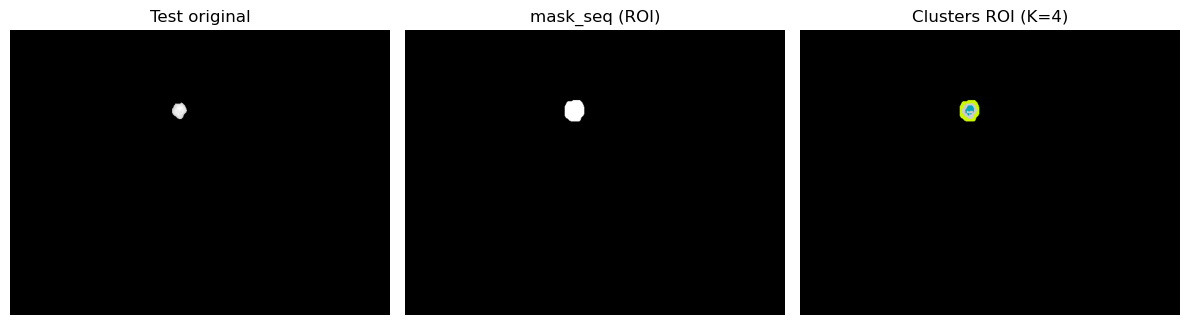

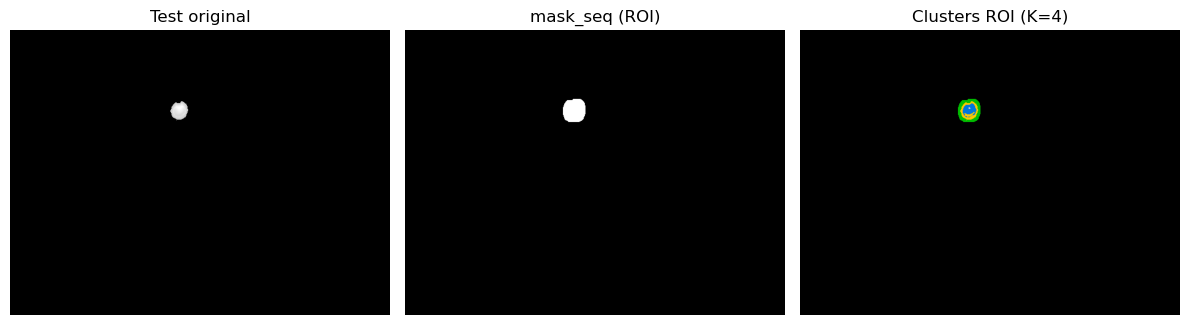

  Tiempo aplicar test: 3.51 s

✅ Terminado. Resultados en: C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\out_kmeans_metodo2
Tiempo total: 3.55 s


In [ ]:
import os
import time
import csv
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

TRAIN_DIR = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\Data2"
TEST_DIR  = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test"
OUT_DIR   = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\out_kmeans_metodo2"

#Variables
K = 4  # 3 o 4

MAX_SAMPLES = 500_000    # total pixeles ROI para entrenar
PER_IMAGE_CAP = 8_000    # máximo pixeles ROI por imagen
SEED = 42

KMEANS_ATTEMPTS = 3
KMEANS_MAXITER = 40
KMEANS_EPS = 0.5

SHOW_EXAMPLES = 2        # 0 si no quieres plots

os.makedirs(OUT_DIR, exist_ok=True)

def list_imgs(folder):
    return sorted(
        glob(os.path.join(folder, "*.tif")) +
        glob(os.path.join(folder, "*.tiff")) +
        glob(os.path.join(folder, "*.png")) +
        glob(os.path.join(folder, "*.jpg")) +
        glob(os.path.join(folder, "*.jpeg"))
    )

def ensure_uint8_gray(img):
    if img is None:
        return None
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return img

#Imagen ROI
def roi_mask_seq_method2(img_in):
    img = ensure_uint8_gray(img_in)
    if img is None:
        return None

    # Filtro (como tu método)
    blurred = cv2.GaussianBlur(img, (5, 5), 0)

    # Canny adaptativo con mediana
    v = np.median(blurred)
    sigma = 0.10
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    edges = cv2.Canny(blurred, lower, upper)

    # Morfología para cerrar huecos + dilatar (como tu flujo)
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)
    dilated = cv2.dilate(closed, kernel, iterations=2)

    # Contorno mayor -> máscara rellena (mask_seq)
    mask_seq = np.zeros_like(img, dtype=np.uint8)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask_seq, [c], -1, 255, -1)

    # Asegurar componente más grande (extra robustez)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_seq, 8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        clean = np.zeros_like(mask_seq)
        clean[labels == largest] = 255
        mask_seq = clean

    return mask_seq

#MUESTREO PIXELES ROI
def collect_roi_pixels_stream(train_paths, max_samples, per_image_cap, seed=42):
    rng = np.random.default_rng(seed)
    samples = []
    total = 0

    for p in train_paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        m = roi_mask_seq_method2(img)
        if m is None:
            continue

        vals = img[m > 0].astype(np.float32)
        if vals.size == 0:
            continue

        take = min(per_image_cap, vals.size, max_samples - total)
        if take <= 0:
            break

        idx = rng.choice(vals.size, size=take, replace=False)
        samples.append(vals[idx])
        total += take

        if total >= max_samples:
            break

    if total == 0:
        raise ValueError("No se obtuvieron píxeles ROI (mask_seq vacía). Revisa la ROI del método 2.")

    return np.concatenate(samples).reshape(-1, 1)

# KMEANS + center/min/max
def train_kmeans_1d(pixels, k):
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, KMEANS_MAXITER, KMEANS_EPS)
    compactness, labels, centers = cv2.kmeans(
        pixels, k, None, criteria, KMEANS_ATTEMPTS, cv2.KMEANS_PP_CENTERS
    )
    labels = labels.flatten()
    centers = centers.flatten()

    stats = []
    for i in range(k):
        v = pixels[labels == i]
        if v.size == 0:
            continue
        stats.append((i, float(centers[i]), float(v.min()), float(v.max())))
    stats.sort(key=lambda x: x[1])  # orden por centro
    return float(compactness), centers.astype(np.float32), stats

def assign_clusters_roi(img_gray, mask, centers):
    out = np.zeros_like(img_gray, dtype=np.uint8)
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return out

    vals = img_gray[ys, xs].astype(np.float32)
    d = np.abs(vals.reshape(-1, 1) - centers.reshape(1, -1))
    lab = np.argmin(d, axis=1).astype(np.uint8)

    scale = max(1, int(255 / (len(centers) + 1)))
    out[ys, xs] = (lab + 1) * scale
    return out

#Resultados
train_paths = list_imgs(TRAIN_DIR)
test_paths  = list_imgs(TEST_DIR)

print("Train images:", len(train_paths))
print("Test images :", len(test_paths))
if not train_paths:
    raise ValueError("TRAIN_DIR no tiene imágenes.")
if not test_paths:
    raise ValueError("TEST_DIR no tiene imágenes.")

t0 = time.time()
print("\n[1/4] Muestreando pixeles ROI (mask_seq método 2) del train...")
pixels = collect_roi_pixels_stream(train_paths, MAX_SAMPLES, PER_IMAGE_CAP, SEED)
print("  Pixeles ROI usados:", pixels.shape[0])
print("  Tiempo sampling:", round(time.time() - t0, 2), "s")

t1 = time.time()
print("\n[2/4] Entrenando K-means SOLO en ROI...")
compactness, centers, stats = train_kmeans_1d(pixels, K)
print("  Compactness:", round(compactness, 2))
print("  Tiempo kmeans:", round(time.time() - t1, 2), "s")

# Tabla tipo tu ejemplo
print("\nCluster | Center | Min | Max")
print("-" * 30)
for cid, c, mn, mx in stats:
    print(f"{cid:<7} | {c:>6.2f} | {mn:>3.0f} | {mx:>3.0f}")

# Exportar CSV
csv_path = os.path.join(OUT_DIR, f"clusters_metodo2_maskseq_K{K}.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["cluster_id", "center", "min", "max"])
    for cid, c, mn, mx in stats:
        w.writerow([cid, round(c, 3), round(mn, 3), round(mx, 3)])
print("\n[3/4] CSV guardado:", csv_path)

t2 = time.time()
print("\n[4/4] Aplicando centros al TEST (solo ROI mask_seq método 2) y guardando...")
shown = 0
for p in test_paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    mask = roi_mask_seq_method2(img)
    roi_only = cv2.bitwise_and(img, img, mask=mask)
    clusters_map = assign_clusters_roi(img, mask, centers)

    base = os.path.splitext(os.path.basename(p))[0]
    cv2.imwrite(os.path.join(OUT_DIR, f"{base}_roi.png"), roi_only)
    cv2.imwrite(os.path.join(OUT_DIR, f"{base}_clusters_K{K}.png"), clusters_map)

    if shown < SHOW_EXAMPLES:
        shown += 1
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Test original"); plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(mask, cmap="gray"); plt.title("mask_seq (ROI)"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(clusters_map, cmap="nipy_spectral"); plt.title(f"Clusters ROI (K={K})"); plt.axis("off")
        plt.tight_layout()
        plt.show()

print("  Tiempo aplicar test:", round(time.time() - t2, 2), "s")
print("\n✅ Terminado. Resultados en:", OUT_DIR)
print("Tiempo total:", round(time.time() - t0, 2), "s")